In [ ]:
## problem 1


from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [410]:
##2 Problem class


class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass


In [ ]:
## Node Class


@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost


def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])


In [ ]:
##3 GridProblem class

MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:

        if state == self.goal:
            return True
        else:
            return False

        # Return True if state is equal to the goal state.

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:

        # Return a list of legal action names.
        legal_actions = []
        row, col = state

        for action, (dr, dc) in MOVES.items():
            new_row = row + dr
            new_col = col + dc

            ## check new position within bounds
            if 0 <= new_row < self.rows and 0 <= new_col < self.cols:
                ## check if the cell is free
                if self.grid[new_row][new_col] == 0:
                    legal_actions.append(action)
        return legal_actions
        #

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.

        row, col = state
        dr, dc = MOVES[action]

        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        return 1.0
        ##raise NotImplementedError("Complete GridProblem.action_cost")


In [ ]:
###SearchAlgortithm class


class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:

        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        s = node.state
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    #     s_prime <- problem.RESULT(s, action)
    #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
    #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
    # raise NotImplementedError("Complete SearchAlgorithm.expand")

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass


def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()


In [ ]:
## 3.Weighted grid Problem
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 1:
        # Return the cost of moving from state to next_state.
        row, col = next_state
        return self.terrain_costs[row][col]
        #
        # Steps:
        # 1. Unpack next_state into row and col.
        # 2. Return self.terrain_costs[row][col].
        raise NotImplementedError("Complete WeightedGridProblem.action_cost")


In [ ]:
## Test code

wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
#
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")


WeightedGridProblem self-check passed.


In [ ]:
##Heuristic Functions


def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:

    # TODO 2:
    # Return the Manhattan distance between state and goal.
    r1, c1 = state
    r2, c2 = goal
    return abs(r1 - r2) + abs(c1 - c2)

    #
    # Steps:
    # 1. Unpack state into (r1, c1) and goal into (r2, c2).
    # 2. Return abs(r1 - r2) + abs(c1 - c2).
    raise NotImplementedError("Complete manhattan_distance")


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:
    return math.dist(state, goal)
    # Return the straight-line distance between state and goal.
    #
    # Hint: math.sqrt(...) or math.dist(state, goal).
    raise NotImplementedError("Complete euclidean_distance")


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0

In [417]:
##'4.2 Self check of Heuristics
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")


Heuristic self-check passed.


In [ ]:
## 5. The Priority Queue Frontier

## Defined class for drone
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0


In [ ]:
## Best First Search(BFS)


class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        # TODO 4:

        ## Initial Node
        node_init = Node(
            state=problem.initial_state(), parent=None, action=None, path_cost=0
        )

        ## Frontier priorityQueue
        frontier = PriorityQueue()
        frontier.push(self.evaluation(node_init, problem), node_init)

        ## dictionary of reached
        reached = {node_init.state: node_init}

        ## counters
        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.pop()

            ## Testing the goal
            if problem.is_goal(node.state):
                return SearchResult(
                    status="success",
                    algorithm=self.algorithm_name,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached),
                    # path = reconstruct_path(node),
                    solution=node,
                )
            nodes_expanded += 1

            ## Expanded Node
            for child in self.expand(problem, node):
                s = child.state
                if s not in reached or child.path_cost < reached[s].path_cost:
                    reached[s] = child
                    frontier.push(self.evaluation(child, problem), child)

            ## Track frontier size
            max_frontier_size = max(max_frontier_size, len(frontier))

        ## Incase it fails

        return SearchResult(
            status="failure",
            algorithm=self.algorithm_name,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
            # path = None,
            solution=None,
        )

        # Implement the BEST-FIRST-SEARCH pseudocode above.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. Create a PriorityQueue frontier and push the initial node
        #    with priority self.evaluation(node, problem).
        # 3. Create a reached DICTIONARY mapping state -> Node, containing
        #    the initial state.
        # 4. Initialise counters: nodes_expanded = 0, max_frontier_size = 1.
        # 5. While the frontier is not empty:
        #       a. pop the node with the lowest f-value.
        #       b. if problem.is_goal(node.state): return a SearchResult with
        #          status "success" (use self.algorithm_name, nodes_expanded,
        #          max_frontier_size, and len(reached)).
        #       c. increment nodes_expanded.
        #       d. for each child in self.expand(problem, node):
        #             i. s = child.state
        #            ii. if s not in reached OR
        #                   child.path_cost < reached[s].path_cost:
        #                     reached[s] = child
        #                     push child with priority self.evaluation(child, problem)
        #       e. update max_frontier_size with len(frontier).
        # 6. If the loop ends, return a SearchResult with status "failure"
        #    and solution=None.
        ##raise NotImplementedError("Complete BestFirstSearch.search")

In [ ]:
## Greedy Best-First Search
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5:
        # Greedy Best-First Search: f(n) = h(n).
        return self.h(node, problem)
        # raise NotImplementedError("Complete GreedyBestFirstSearch.evaluation")

In [ ]:
##A* Search
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6:
        # A* search: f(n) = g(n) + h(n).
        return node.path_cost + self.h(node, problem)
        ##raise NotImplementedError("Complete AStarSearch.evaluation")


In [422]:
##9 UCS as special case, weight is 0
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

In [ ]:
## 10.Weighted A* Search
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7:
        return node.path_cost + self.weight * self.h(node, problem)
        # Weighted A*: f(n) = g(n) + W * h(n).
        ##raise NotImplementedError("Complete WeightedAStarSearch.evaluation")


In [ ]:
### 10.1 Test Code

check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, (
        f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    )
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0], [1, 1, 0], [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")


Algorithm self-check passed.


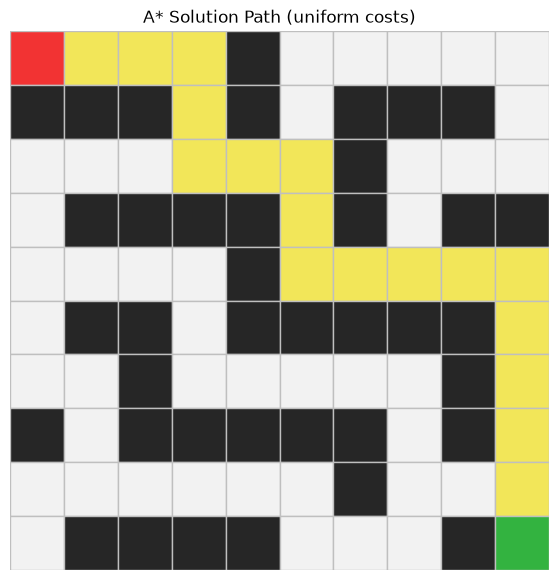

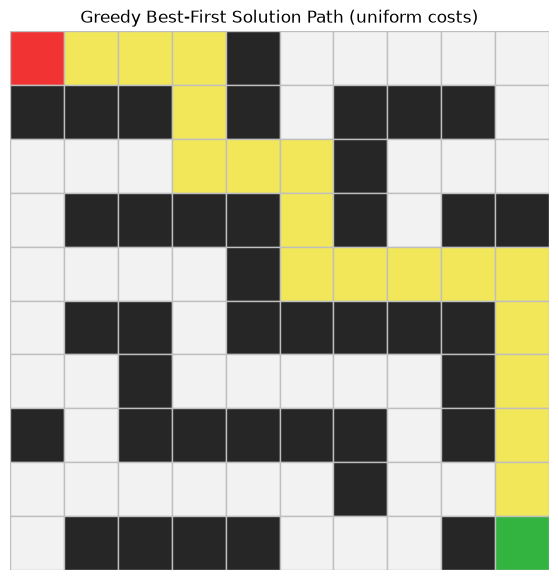

In [ ]:
## Part A sample as test of the Uniform search algorithms

sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)


# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)


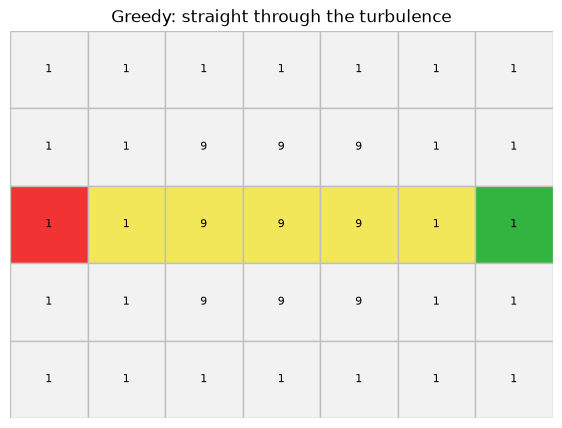

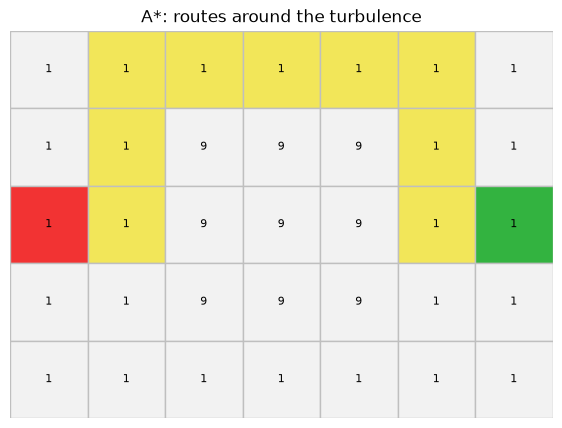

In [ ]:
## 12.The turbulance map

turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)


# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

In [ ]:
## building inflated


def inflated_heuristic(factor: float):
    # TODO 8:
    def h(state, goal):
        return factor * manhattan_distance(state, goal)

    return h


mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18.0,18,5,23
1,A* inflated x3 (uniform map),success,18,18.0,18,5,23
2,A* admissible (mild turbulence),success,10,10.0,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12.0,6,13,19


    Algorithm	                    Status	  Solution depth	  Solution cost	  Nodes expanded	  Max frontier	  Reached states

0 A* admissible (uniform map) success 18 18.0 18 5 23
1 A* inflated x3 (uniform map) success 18 18.0 18 5 23
2 A* admissible (mild turbulence) success 10 10.0 29 10 35
3 A* inflated x3 (mild turbulence) success 6 12.0 6 13 19

1.The inflated heuristic becames suboptimal on the mild turbulance map. From the results , on the uniform map, both admissible A* and inflated A* found thesame optimal path making the cost thesame Whereas on the mild turbulance map, inflated A* chooses a staight-path making and routes the drone through the high-cost band making its cost 2 units worst of the admissible A*.

2. inflated A* expanded fewer nodes than admissible A* in the turbulance map. admisssible A* expanded 21 more nodes than the inflated A* in th turbulance map

3. As an engineer, I would accept an inadmissible heuristic when speed is more important than optimality
   When I am making a real-time decision in designing robots, games and probably building a rout or navigation set up.

4.


In [ ]:
####Trial
class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def h(self, state, goal):
        return self.heuristic(state, goal)

    def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:

        start = problem.initial_state()

        def f(state, g):
            return g + self.heuristic(state, problem.goal)

        # Node structure: (state, g_cost, path)
        def dfs(state, g, path, limit):
            nonlocal nodes_expanded, next_limit

            nodes_expanded += 1

            f_cost = g + self.heuristic(state, problem.goal)

            # prune
            if f_cost > limit:
                next_limit = min(next_limit, f_cost)
                return None

            if problem.is_goal(state):
                return path

            for action in problem.actions(state):
                child_state = problem.result(state, action)

                # cycle check (path-based)
                if child_state in path:
                    continue

                result = dfs(
                    child_state,
                    g + problem.action_cost(state, action, child_state),
                    path + [child_state],
                    limit,
                )

                if result is not None:
                    return result

            return None

        # initial threshold
        threshold = self.heuristic(start, problem.goal)

        nodes_expanded = 0
        iterations = []

        for i in range(max_iterations):
            next_limit = float("inf")

            result = dfs(start, 0, [start], threshold)

            if result is not None:
                return SearchResult(
                    status="success",
                    algorithm=self.algorithm_name,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=i + 1,
                    reached_count=len(result),
                    solution=result,
                    iterations=iterations,
                )

            iterations.append((threshold, next_limit))

            if next_limit == float("inf"):
                return SearchResult(
                    status="failure",
                    algorithm=self.algorithm_name,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=i + 1,
                    reached_count=0,
                    solution=None,
                    iterations=iterations,
                )

            threshold = next_limit

        return SearchResult(
            status="cutoff",
            algorithm=self.algorithm_name,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_iterations,
            reached_count=0,
            solution=None,
            iterations=iterations,
        )

In [ ]:
## 15. Create Your Own Maps


# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]


custom_costs_1 = [[1 for _ in range(20)] for _ in range(20)]

custom_start_1 = (0, 0)
custom_goal_1 = (19, 19)
# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

custom_results_1 = [
    UniformCostSearch().search(custom_problem_1),
    GreedyBestFirstSearch(manhattan_distance).search(custom_problem_1),
    AStarSearch(manhattan_distance).search(custom_problem_1),
    WeightedAStarSearch(manhattan_distance, weight=2).search(custom_problem_1),
]

show_results(custom_results_1)


#

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,38,38.0,75,2,76
1,Greedy,success,38,38.0,38,2,40
2,A*,success,38,38.0,75,2,76
3,Weighted A* (W=2),success,38,38.0,38,2,40


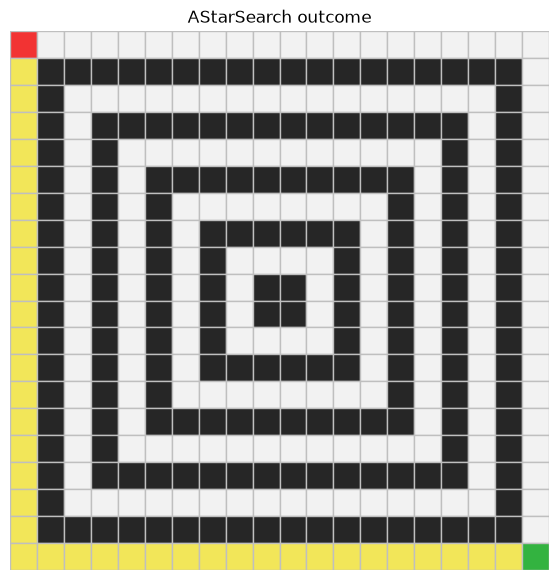

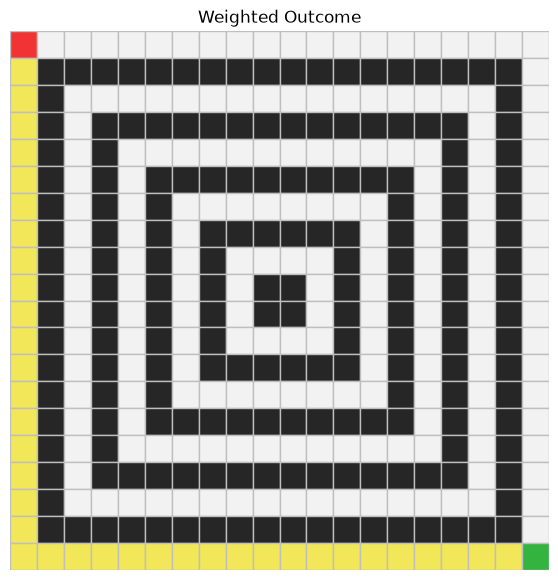

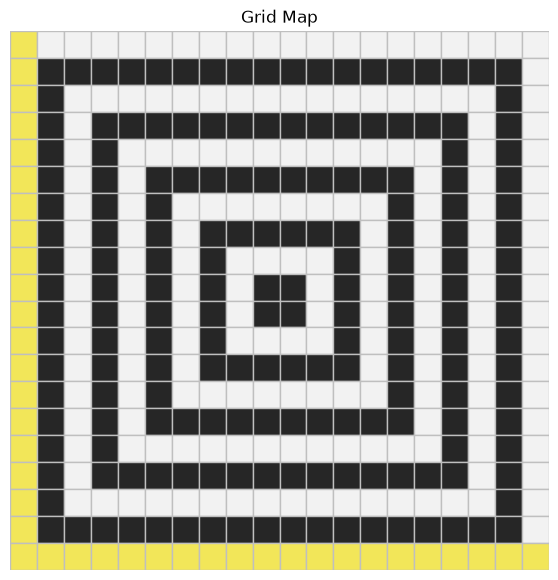

In [ ]:
# A* visualization
astar_result = AStarSearch(manhattan_distance).search(custom_problem_1)

plot_path(
    custom_problem_1.grid,
    start=custom_start_1,
    goal=custom_goal_1,
    path=astar_result.path,
    title="AStarSearch outcome",
)

weighted_result_1 = WeightedAStarSearch(manhattan_distance, weight=2).search(
    custom_problem_1
)

##Weigted A* Visualization
plot_path(
    custom_problem_1.grid,
    start=custom_start_1,
    goal=custom_goal_1,
    path=weighted_result_1.path,
    title="Weighted Outcome",
)

ucs_result_1 = UniformCostSearch().search(custom_problem_1)

plot_path(custom_problem_1.grid, path=ucs_result_1.path)

All the algorithms successfully found a path to the goal and produced the same solution cost. The main difference was in the number of nodes expanded. UCS explored more of the search space because it had no heuristic guidance, while Greedy and Weighted A* reached the goal with fewer expansions. A* provided a balance between optimality and search efficiency.


A\* found the optimal path while expanding fewer nodes guided toward the goal


In [ ]:
## 15. Create Your Own Maps


# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_costs_2 = [
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 5, 5, 5, 5, 5, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 5, 1, 1, 1, 5, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 5, 1, 1, 1, 5, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 5, 5, 5, 5, 5, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
]
custom_start_2 = (0, 0)
custom_goal_2 = (14, 14)
# Example after completing:
custom_problem_2 = WeightedGridProblem(
    custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
)

custom_results_2 = [
    UniformCostSearch().search(custom_problem_2),
    GreedyBestFirstSearch(manhattan_distance).search(custom_problem_2),
    AStarSearch(manhattan_distance).search(custom_problem_2),
    WeightedAStarSearch(manhattan_distance, weight=2).search(custom_problem_2),
]

show_results(custom_results_2)


,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,28,28,159,10,160
1,Greedy,success,28,28,28,22,50
2,A*,success,28,28,159,10,160
3,Weighted A* (W=2),success,28,28,28,22,50


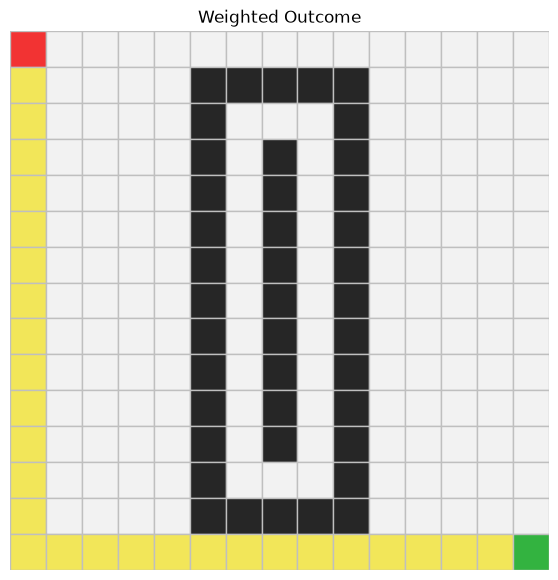

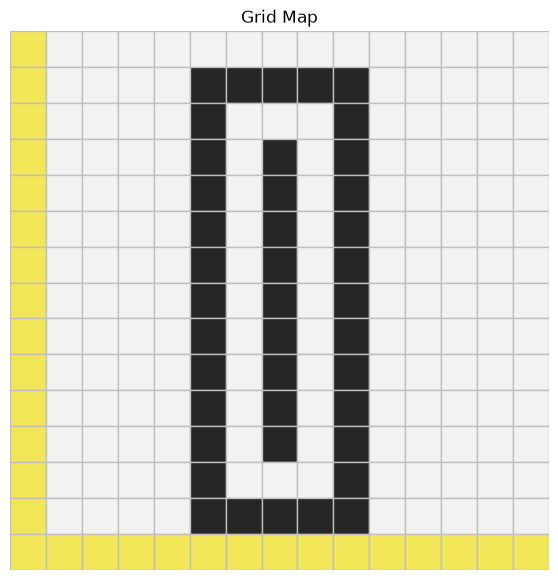

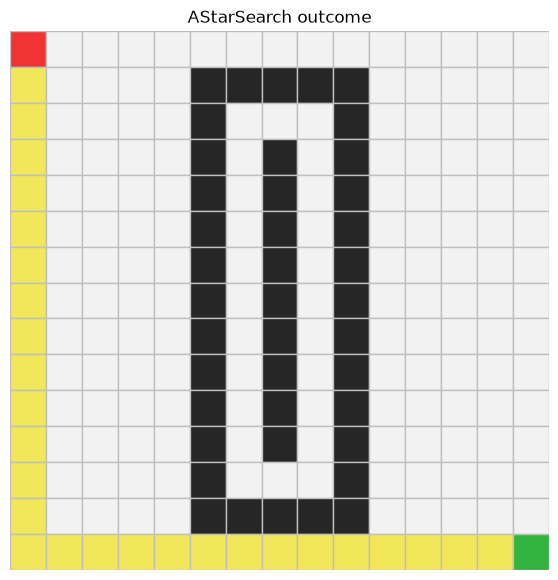

In [ ]:
##Weigted A* Visualization
weighted_result_1 = WeightedAStarSearch(manhattan_distance, weight=3).search(
    custom_problem_2
)

plot_path(
    custom_problem_2.grid,
    start=custom_start_2,
    goal=custom_goal_2,
    path=weighted_result_1.path,
    title="Weighted Outcome",
)


## UCS visualization
ucs_result_1 = UniformCostSearch().search(custom_problem_2)

plot_path(custom_problem_2.grid, path=ucs_result_1.path)


##A* visualization.
astar_result = AStarSearch(manhattan_distance).search(custom_problem_2)

plot_path(
    custom_problem_2.grid,
    start=custom_start_2,
    goal=custom_goal_2,
    path=astar_result.path,
    title="AStarSearch outcome",
)

##interpretation for second map

Although the map included weighted terrain, the optimal route was sufficiently clear that all three cost-sensitive algorithms selected the same path. This demonstrates that heuristics affect how the search is conducted, but they do not necessarily change the final solution when one route is clearly superior.


##Reflections

16.1

1.  h(n) estimates the estimated remaining cost from the current state to the goal state. In this lab, its knowledge comes from the problem design or geometry, the grid layout and the goal position.

    2.The relaxation removes:
    obstacles like walls.
    terrain cost differences .
    any change that is forced by blocked cells.
    It simply assumes the drone can move freely in a straight grid path.

    3.Manhattan dominates the Euclidean on the grid because :
    it is more informed as in closeness to the true cost.
    A\* when used with manhattan, expands fewer (sometimes) or equal nodes compared to Euclidean.

2.  Ensuring cost >=1 ensures that every step costs at least the Manhattan estimate. This makes the heuristic plausibly admissible.
    if a terrain cost = 0.50:
    actual paths will become cheaper than the heuristic predicts.
    Manhattan distance could overestimate or probably misrepresent the true cost.
    A\* optimality stance may also break.

#########

16.2

1. Gready ignores the cost so far that is the g(n) and only considers the h(n). In the turbulance map, it orientation forced it to choose direct paths through an expensive terrain.

2. For a fact that greedy is not optimal , it may:
   find longer or more expensive paths( what happened in the turbulance map case).
   get misled by poor heuristics.

   Hence fewer nodes expansion only measures spead not solution quality

3. greedy is acceptable when environment is well-known.
   greedy is acceptable when environment is simple.
   greedy is acceptable when a faster reaction is important than path optimality.
   the system is used for emergency activities.

#########

16.3

    1. the equation f(n) = g(n) = h(n) mean the A* chooses path based on:
                  the cost already spent and the estimated cost remaining.
      thefore making  selection of path based on the cheapest in expected cost


    2.
       An ealier generated goal node might not be optimal
       So stopping might return a suboptimal path.


    3.
      A  set only tracks whether a state has been seen but a dictionary stores th best cost so far node for each state, allowing updates if a cheaper path is found later.

4.  A* expands fewer nodes because the heauristic guides the search toward the goal whereas the UCS does the search blindly. This gap shows that a good heuristic reduces the search space significantly for searches like A* compared to UCS.

#########

16.4

    1.
    Admissible heuristic is when a heuristic never overestimates the true cost to goal
    Consistent heuristic is a heuristic that satifies the triangle inequality (h(n) <= c(n, a, n*)+h(n*))
    the consistent heuristic implies the admissibe heuristic.

2.  The experiment showed how the inflated heuristic broke admissibility and ended in suboptimal solutions. The further confirms that optimality in the A\* depends on admissibility

3.  For now, Manhattan is consistent as moving cost at least 1 and distance changes by at most 1 per step

#########

16.5

      1.
      when weight(w) = 0 it uses uniform-cost search
                 w = 1 it, assumes the A* search
                 w = large , it becomes greedy.

      2.
         Weighted A* guarantees solution cost<= weight * optimal cost to grant a suboptimality bound
         My experiements stayed within the above bound since I chose a weight of 2 which is moderate.


      3.
        I would choose weighted A* with weight of approximately 2 because :
            it balances good solution quality, faster computation and real-time responsivesness.

##########

16.6

    1.
       A*  stores all frontier and reached nodes  consuming a lot of memory
        IDA avoids this by using a depth-first-search with ierative or depth measures which considers only the current path to be commited to memory

        Trade-Off: the IDA will need to recompute alot, using less memory.

    2.
      Wind spead and directon
      Weather conditions
      battery consumption rate
      dynamic obstacles
      restricted or no-fly zones.

    3.
       Since the heuristic assume a fixed goal. if the goal moves:
          h(n) becomes outdated.
          paths may become invalid .

          Thus making real-time and learned heuristics essential.


    4.
     I would ship A* depending on constraints
         if accuracy is critical or core
          I would reconsider if :
           environment becomes dynamic  and memory becomes limited.

Notes:
The astericks denotes a new reflection( transition eg 16.1 ends and 16.2 begins)
